In [10]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300


In [11]:
net_df: pd.DataFrame
net_df_2: pd.DataFrame

In [12]:

class NodeOutCol:
    """Many not included here"""
    TS_ABS = "timestamp_absolute"
    MIN_F_TPUT = "min_flow_throughput_ratio"
    MAX_F_TPUT = "max_flow_throughput_ratio"
    AVG_F_YPU_RATIO = "avg_flow_throughput_ratio"
    TOT_TPUT_RATIO = "node_throughput_ratio"
    CURR_PWR_USE = "power_draw_watts"
    EN_USE = "energy_consumed_joule"

In [13]:

class NetOutCol:
    """Many not included here"""
    TS_ABS = "timestamp_absolute"
    NUM_FLOWS = "flows"
    AVG_TPUT_RATIO = "avg_throughput_ratio"
    TOT_TPUT_RATIO = "tot_tput_ratio"
    TOT_TPUT = "tot_tput_mbps"
    WORST_TPUT_RATIO = "worst_tput_ratio"
    CURR_PWR_USE = "power_draw_watt"
    EN_USE = "energy_consumed_joule"

In [14]:
# Path to the folder where the raw network output is.
network_output_folder: str = "../test/100MbpsOSPF/networking/"
# ===================================================

node_df = pd.read_parquet(f'{network_output_folder}/node.parquet', engine='pyarrow')
net_df = pd.read_parquet(f'{network_output_folder}/network.parquet', engine='pyarrow')

In [15]:
# Path to the folder where the raw network output is.
network_output_folder_2: str = "../test/100MbpsECMP/networking/"
# ===================================================

node_df_2 = pd.read_parquet(f'{network_output_folder_2}/node.parquet', engine='pyarrow')
net_df_2 = pd.read_parquet(f'{network_output_folder_2}/network.parquet', engine='pyarrow')

In [16]:
from functools import reduce

def reduce_granularity(x: list, by: float) -> list:
    newX: list = list()
    size: int = len(x)
    remaining: int = size
    while remaining > by:
        subX = x[remaining-by: remaining]
        avgX = reduce(lambda x, y: x + y, subX) / float(len(subX))
        newX.append(avgX)

        remaining -= by

    return newX

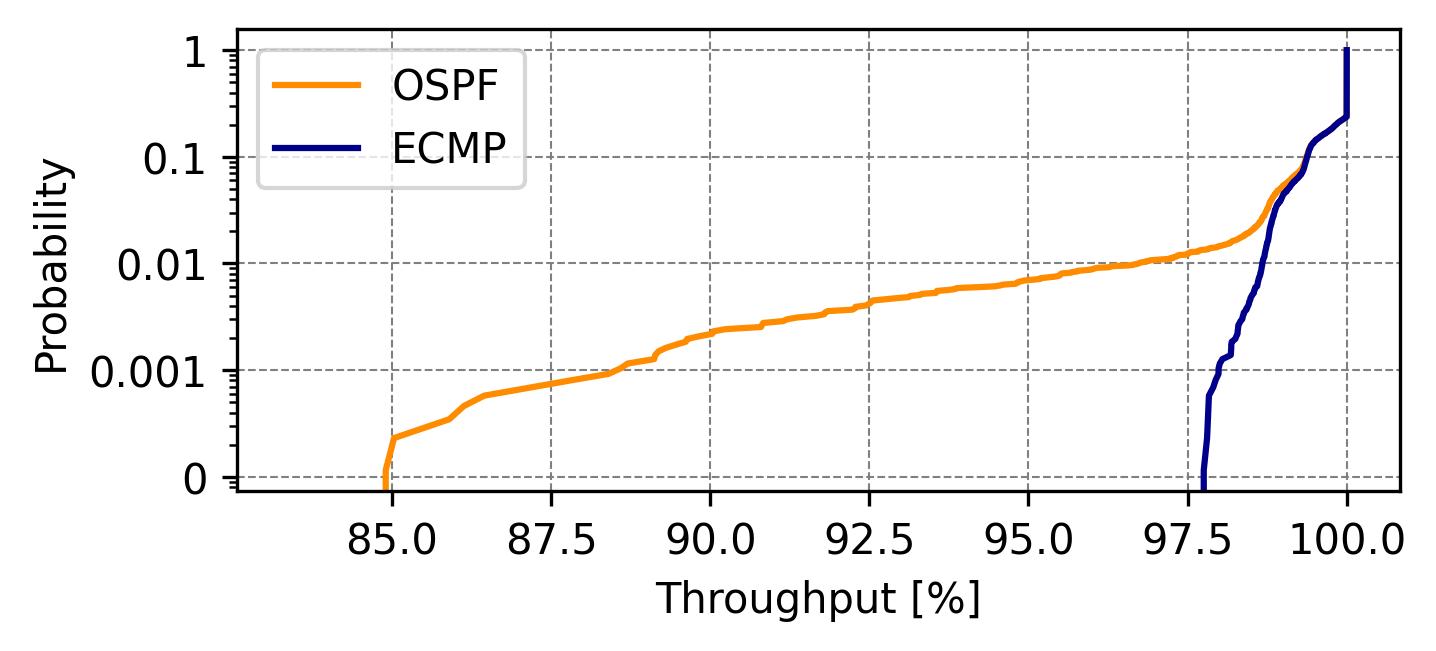

In [75]:
import matplotlib.ticker as ticker

# Create avg tput plot
def avg_tpu_plot():
    
    plt.figure(figsize=(5,2))
    def compute_rcdf(data):
        """Compute RCDF from raw data."""
        sorted_data = np.sort(data)[::-1]  # Sort the data
        cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Compute CDF
        rcdf = 1 - cdf  # Compute RCDF
        return sorted_data, rcdf

    tput1 = list(map(lambda x: x * 100, net_df[NetOutCol.AVG_TPUT_RATIO]))
    tput2 = list(map(lambda x: x * 100, net_df_2[NetOutCol.AVG_TPUT_RATIO]))
    x1, y1 = compute_rcdf(tput1)
    x2, y2 = compute_rcdf(tput2)
    
    plt.plot(x1, y1, label="OSPF", color="darkorange")
    plt.plot(x2, y2, label="ECMP", color="darkblue")
    plt.yscale("log")

    def format_func(value, tick_position):
        return f'{value:.3f}'.rstrip('0').rstrip('.') if value != 0 else '0'
    
    # Apply the custom formatter to y-axis
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    
    plt.legend(loc="best")
    plt.xlabel("Throughput [%]")
    plt.ylabel("Probability")

    plt.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5, color='gray')

    
avg_tpu_plot()

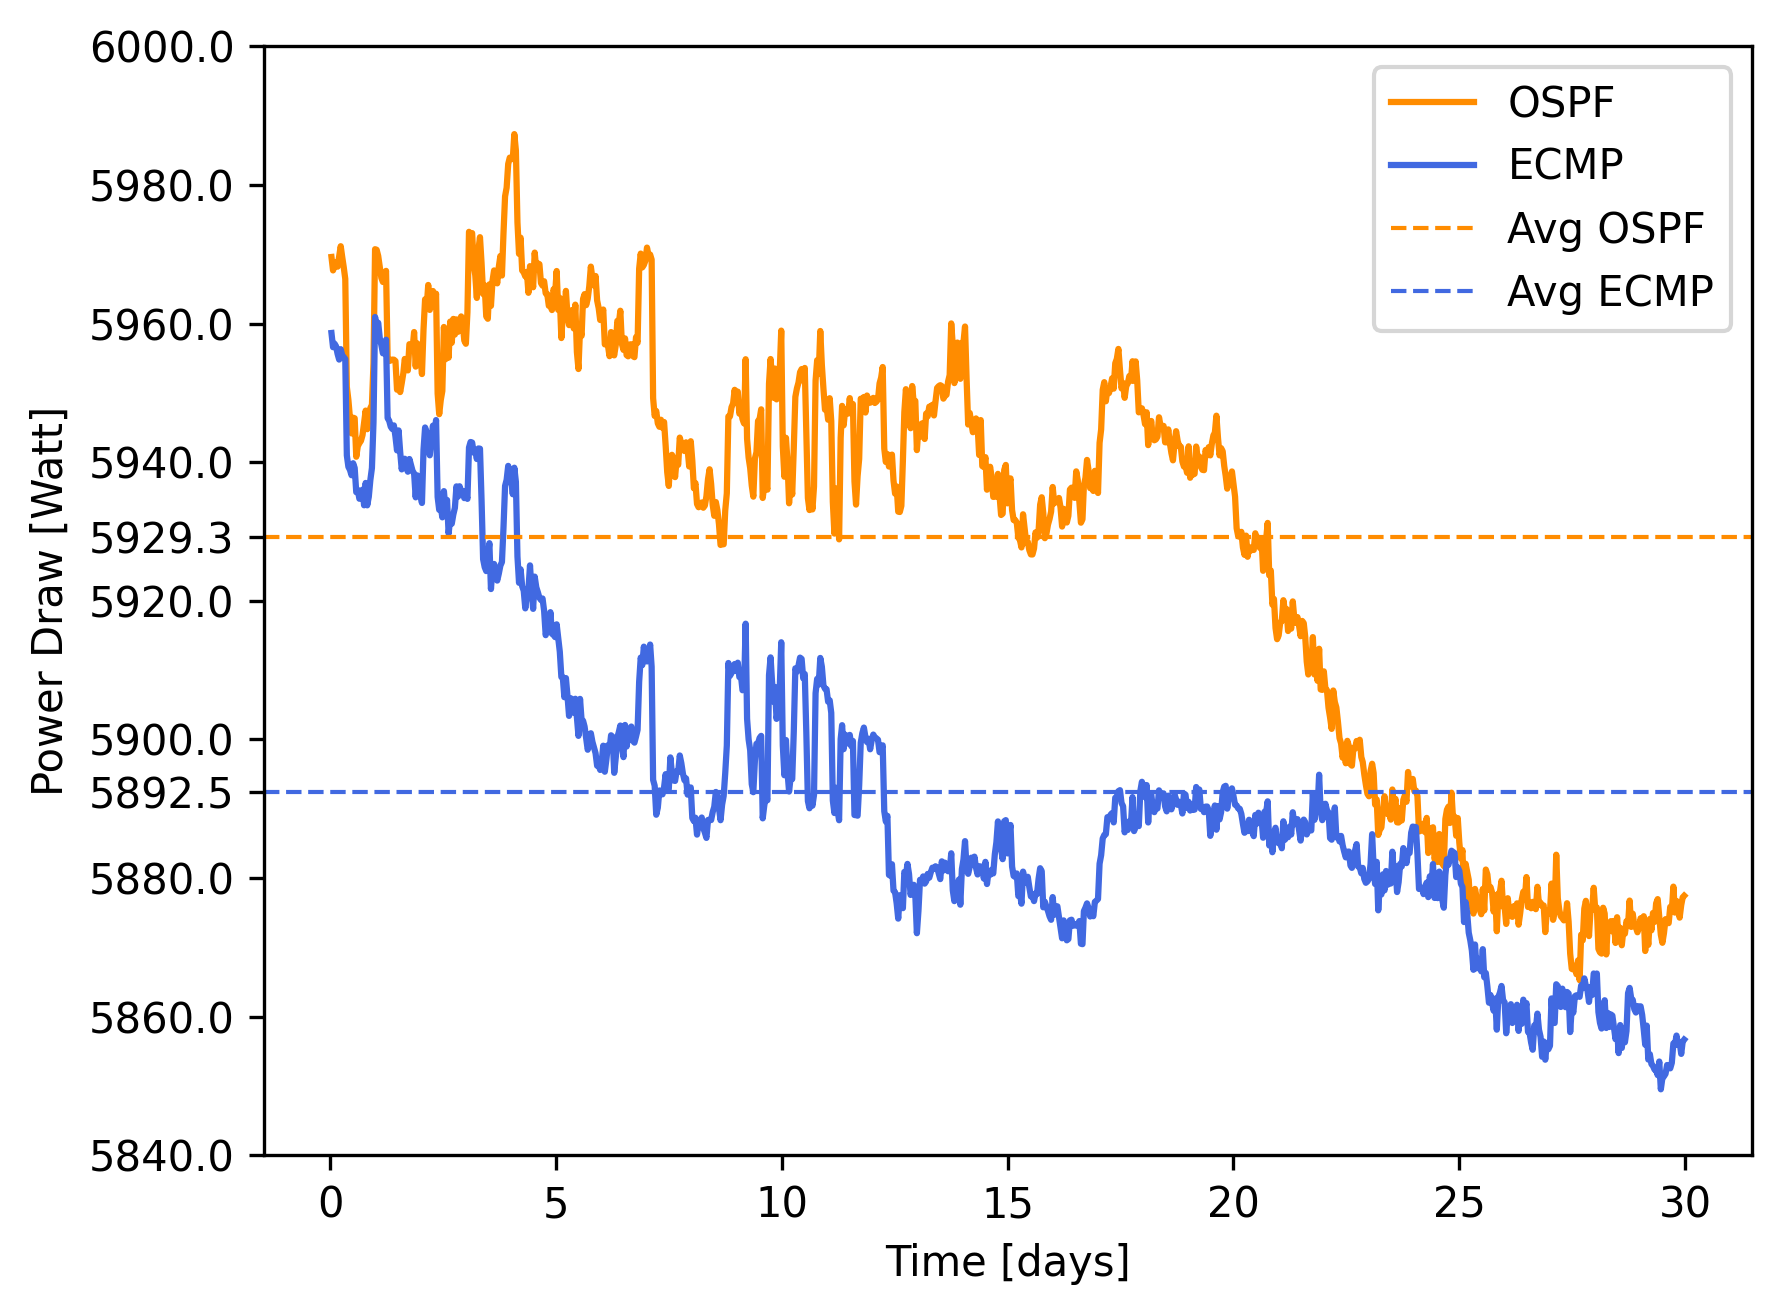

In [ ]:
def pwr_plot():
    REDUCE_GRANULARITY_BY: int = 10

    min_ts = net_df[NetOutCol.TS_ABS].min()
    rel_ts = list(map(lambda x: (x - min_ts) / 1000 / 60 / 60 / 24, net_df[NetOutCol.TS_ABS]))
    rel_ts = reduce_granularity(rel_ts, REDUCE_GRANULARITY_BY)
    # pwr_use_1 = reduce_granularity(net_df[NetOutCol.CURR_PWR_USE], REDUCE_GRANULARITY_BY)
    # pwr_use_2 = reduce_granularity(net_df_2[NetOutCol.CURR_PWR_USE], REDUCE_GRANULARITY_BY)

    plt.xlabel("Time [days]")
    plt.ylabel("Power Draw [Watt]")
    plt.plot(rel_ts, pwr_use_1, color="darkorange", label="OSPF")
    plt.plot(rel_ts, pwr_use_2, color="royalblue", label="ECMP")


    plt.axhline(y=np.nanmean(pwr_use_1), color="darkorange", linestyle='--', linewidth=1, label='Avg OSPF')
    plt.axhline(y=np.nanmean(pwr_use_2), color="royalblue", linestyle='--', linewidth=1, label='Avg ECMP')
    plt.yticks(list(plt.yticks()[0]) + [np.nanmean(pwr_use_1)])
    plt.yticks(list(plt.yticks()[0]) + [np.nanmean(pwr_use_2)])
    plt.legend(loc="best")

    
pwr_plot()

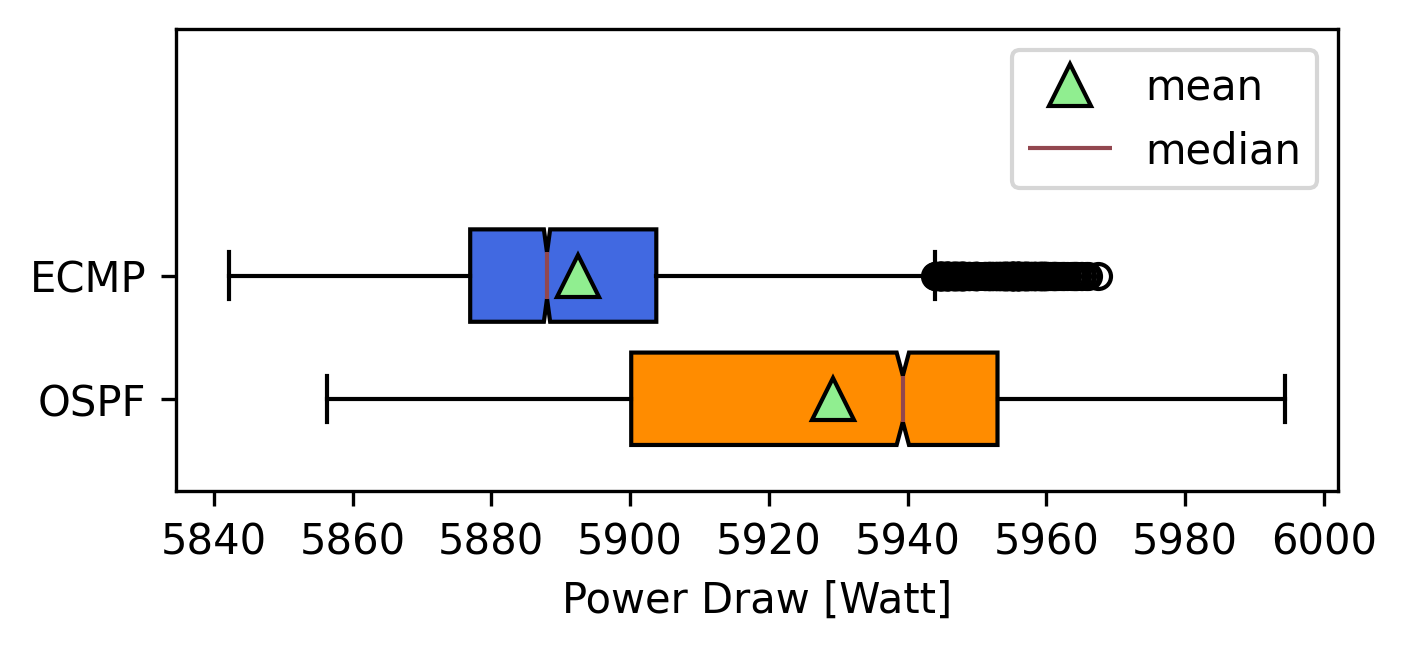

In [76]:
def pwr_boxplot():
    plt.figure(figsize=(5,2))

    pwr_use = [net_df[NetOutCol.CURR_PWR_USE], net_df_2[NetOutCol.CURR_PWR_USE]]

    bp = plt.boxplot(
        pwr_use, 
        vert=False, 
        widths=0.6, 
        positions=[0.6, 1.4], 
        patch_artist=True, 
        notch=True, 
        showmeans=True,
        meanprops={'markerfacecolor': "lightgreen", 'markeredgecolor': "black", 'markersize': 10}
    )

    plt.xlabel("Power Draw [Watt]")
    bp["boxes"][0].set_facecolor("darkorange")
    bp["boxes"][1].set_facecolor("royalblue")
    for median in bp["medians"]:
        median.set_color("#92474F")
    plt.yticks([0.6, 1.4], ["OSPF", "ECMP"])
    plt.ylim(0, 3)
    
    plt.legend([bp['means'][0], bp["medians"][0]], ['mean', 'median'], loc ="best")
 
pwr_boxplot()   